In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os

## Exercise 1.1: Plot x*sin(x)

In [40]:
# Function provided

def func(x):
  return x*np.sin(x)

In [41]:
# Uniformly spaced points in interval

x_data = np.linspace(0, 10, 50)
y_data = func(x_data)

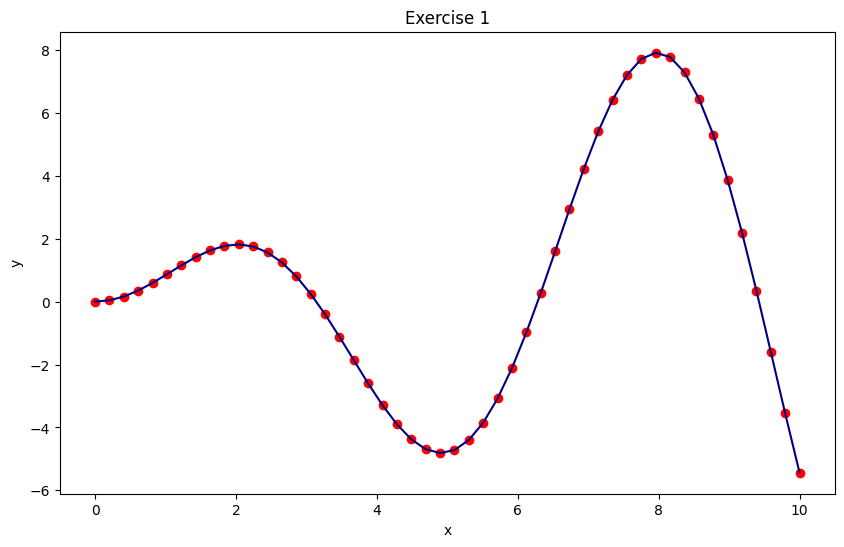

In [42]:
# Plotting the figure

plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data, color="navy")
plt.scatter(x_data, y_data, color="red")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Exercise 1")
plt.show()

## Exericse 1.2: Create Pandas Dataframe

In [43]:
# Creating the dataframe

my_df = pd.DataFrame({"x_data": x_data, "y_data": y_data})

In [71]:
# Converting to pickle file

os.makedirs('your_data', exist_ok=True)

my_df.to_pickle('your_data/exercise1_data.pkl')

my_df.head()

,x_data,y_data
0,0.000000,0.000000
1,0.204082,0.041361
2,0.408163,0.162010
3,0.612245,0.351861
4,0.816327,0.594804


In [72]:
from google.colab import files
files.download('your_data/exercise1_data.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Exercise 1.3: Load Pandas Dataframe

In [74]:
!git clone https://github.com/ShreyaDee14/dlps.git

Cloning into 'dlps'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 23 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 46.39 KiB | 1.19 MiB/s, done.


In [75]:
# Verifying whether it is the same dataframe
my_loaded_df = pd.read_pickle('dlps/your_data/exercise1_data.pkl')
print(my_loaded_df)

       x_data    y_data
0    0.000000  0.000000
1    0.204082  0.041361
2    0.408163  0.162010
3    0.612245  0.351861
4    0.816327  0.594804
5    1.020408  0.869716
6    1.224490  1.151795
7    1.428571  1.414147
8    1.632653  1.629531
9    1.836735  1.772167
10   2.040816  1.819509
11   2.244898  1.753867
12   2.448980  1.563797
13   2.653061  1.245160
14   2.857143  0.801798
15   3.061224  0.245760
16   3.265306 -0.402933
17   3.469388 -1.116991
18   3.673469 -1.863006
19   3.877551 -2.602991
20   4.081633 -3.296252
21   4.285714 -3.901487
22   4.489796 -4.379025
23   4.693878 -4.693073
24   4.897959 -4.813867
25   5.102041 -4.719599
26   5.306122 -4.398021
27   5.510204 -3.847623
28   5.714286 -3.078316
29   5.918367 -2.111551
30   6.122449 -0.979868
31   6.326531  0.274140
32   6.530612  1.599413
33   6.734694  2.938505
34   6.938776  4.230066
35   7.142857  5.411632
36   7.346939  6.422579
37   7.551020  7.207126
38   7.755102  7.717221
39   7.959184  7.915180
40   8.163265  7

## Exercise 2.1: Probability of z <= 0.52 seconds

In [78]:
from scipy.stats import norm

s = -1.96
prob_s = norm.cdf(s)

# P(z <= 0.52) = P(s <= -1.96)
print(f"Probability P(Z < {s}): {prob_s:.4f}")

Probability P(Z < -1.96): 0.0250


## Exercise 2.2: Expected value of reaction time z
### Solution: E[z] = 1.5
## Exercise 2.3: Expected value of stopping distance

In [79]:
pip install sympy

In [84]:
from sympy import symbols
from sympy.stats import E, Normal, variance

z = Normal('z', 1.5, 0.5)
x = symbols('x')

eqn = z*x + 0.1*x**2

expected_z = E(eqn)

print(f"The expected value of E({eqn}) is: {expected_z}")

The expected value of E(0.1*x**2 + x*z) is: 0.1*x**2 + 1.5*x


## Exercise 2.4: Variance of stopping distance

In [85]:
var_z = variance(eqn)
print(f"The expected value of Variance({eqn}) is: {var_z}")

The expected value of Variance(0.1*x**2 + x*z) is: 0.25*x**2


## Exercise 3.1: Modified Gram Schmidt

In [45]:
# Input the number of dimensions and the vectors that are required (vectors taken from question)

k = input("Your vectors belong in R^k space, where k = ?")
k = int(k)
print("\nGreat, your vectors belong in the {}-dimensional space!".format(k))
all_vecs = []
for i in range(k):
  vec_input_str = input(f"\nPlease enter your {i}th vector in {k} dimensional format (e.g., '1,2,3,...,k'): ")
  current_vector = [float(x.strip()) for x in vec_input_str.split(',')]
  all_vecs.append(current_vector)
  assert len(current_vector) == k
print("\nEntered vectors are:", all_vecs)

Your vectors belong in R^k space, where k = ?3

Great, your vectors belong in the 3-dimensional space!

Please enter your 0th vector in 3 dimensional format (e.g., '1,2,3,...,k'): 1,2,2

Please enter your 1th vector in 3 dimensional format (e.g., '1,2,3,...,k'): -1,0,2

Please enter your 2th vector in 3 dimensional format (e.g., '1,2,3,...,k'): 0,0,1

Entered vectors are: [[1.0, 2.0, 2.0], [-1.0, 0.0, 2.0], [0.0, 0.0, 1.0]]


In [46]:
# L2 norm calculation

def norm_vec(vec):
  return np.sqrt(sum([x**2 for x in vec]))

In [47]:
# Function for MGS

def modified_Gram_Schmidt(vectors):
  q = vectors.copy()
  for i in range(k):
    q[i] = q[i] / norm_vec(q[i])

    for j in range(i+1, k):
      q[j] = q[j] - np.dot(q[i], q[j]) * q[i]

  return q

In [48]:
# MGS on the vectors provided

modified_Gram_Schmidt(all_vecs)

[array([0.33333333, 0.66666667, 0.66666667]),
 array([-0.66666667, -0.33333333,  0.66666667]),
 array([ 0.66666667, -0.66666667,  0.33333333])]

## Exercise 3.2: Singular Value Decomposition

In [49]:
# Input number of rows and columns to create a matrix accordingly

rows = input("Enter number of rows for matrix: ")
columns = input("\nEnter number of columns for matrix: ")

r = int(rows)
c = int(columns)

# Input matrix elements row-wise

print("\nEnter the elements row-wise, separated by spaces (e.g., '1 2 3 ...' for the matrix):")
elements_str = input()
elements = list(map(int, elements_str.split()))

M = np.array(elements).reshape(r, c)

# What the matrix looks like finally

print("\nThe entered matrix is:")
for row_array in M:
    print(row_array)

Enter number of rows for matrix (e.g., 2): 4
Enter number of columns for matrix (e.g., 3): 5
Enter the elements row by row, separated by spaces (e.g., '1 2 3 4 5 6' for a 2x3 matrix):
1 0 0 0 2 0 0 3 0 0 0 0 0 0 0 0 2 0 0 0 
The entered matrix is:
[1 0 0 0 2]
[0 0 3 0 0]
[0 0 0 0 0]
[0 2 0 0 0]


In [50]:
# Performing SVD on matrix using function

def SVD(matrix):
  matrix = np.array(matrix, dtype=float)
  m, n = matrix.shape

  aat = np.dot(matrix, matrix.T) # AA.T
  ata = np.dot(matrix.T, matrix) # A.TA

  # Computing eigenvalues and eigenvectors for both AA.T and A.TA

  eigenvalues_aat, eigenvectors_aat = np.linalg.eig(aat)
  eigenvalues_ata, eigenvectors_ata = np.linalg.eig(ata)

  # Sorting eigenvalues and eigenvectors in descending order

  idx = np.argsort(eigenvalues_ata)[::-1]
  eigenvalues_ata_sorted = eigenvalues_ata[idx]
  eigenvectors_ata_sorted = eigenvectors_ata[:, idx]
  V = eigenvectors_ata_sorted # V obtained

  singular_values = np.sqrt(eigenvalues_ata_sorted)

  # Computing matrix U

  U = np.zeros((m, m))
  r = np.sum(singular_values > 1e-10)

  for i in range(r):
    if singular_values[i] > 1e-10:
        U[:, i] = (matrix @ V[:, i]) / singular_values[i]
    else:
        U[:, i] = np.zeros(m)

  if r < m:
    extra = np.random.randn(m, m - r)

    all_vecs_for_gram = [U[:, i] for i in range(r)] + [extra[:, i] for i in range(m - r)]

    all_vecs_for_gram = [np.array(vec) for vec in all_vecs_for_gram]

    orthonormal = modified_Gram_Schmidt(all_vecs_for_gram)

    for i in range(r, m):
      U[:, i] = orthonormal[i]

  # Finally, matrix Sigma or S

  S = np.zeros((m, n))
  for i in range(min(m, n)):
      if i < len(singular_values):
          S[i, i] = singular_values[i]

  return U, S, V.T

In [51]:
SVD(M) # U, S, and V.T are shown below

(array([[ 0.        , -1.        ,  0.        , -0.06885099],
        [ 1.        ,  0.        ,  0.        ,  0.24487057],
        [ 0.        ,  0.        ,  0.        , -0.97733629],
        [ 0.        ,  0.        ,  1.        ,  0.53081378]]),
 array([[3.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 2.23606798, 0.        , 0.        , 0.        ],
        [0.        , 0.        , 2.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ]]),
 array([[ 0.        ,  0.        ,  1.        ,  0.        ,  0.        ],
        [-0.4472136 ,  0.        ,  0.        ,  0.        , -0.89442719],
        [ 0.        ,  1.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ],
        [-0.89442719,  0.        ,  0.        ,  0.        ,  0.4472136 ]]))

## Exercise 3.3: L2 norm

In [54]:
# L2 norm calculator

def norm_vec(vec):
  return np.sqrt(sum([x**2 for x in vec]))

In [67]:
# Trigonometric vector provided in question
trig_vec = [np.cos(np.pi/4), np.sin(np.pi/4), np.sin(np.pi/8), np.cos(np.pi/8)]

norm_vec(trig_vec)

np.float64(1.4142135623730951)

In [63]:
# For manually entering a vector
N = input("Enter the number of elements in your vector: ")
N = int(N)

def desired_vec():
  my_vec = []
  for i in range(N):
    my_vec.append(float(input(f"Enter the {i+1}th element of your vector: ")))
  return my_vec

Enter the number of elements in your vector: 3


In [66]:
# Example
norm_vec(desired_vec())

Enter the 1th element of your vector: 2
Enter the 2th element of your vector: 3
Enter the 3th element of your vector: 4


np.float64(5.385164807134504)